In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("/kaggle/input/datasets/rabia1zulfiqar/air-quality-data/karachi_training_data.csv")
df.head()

,timestamp,pm2_5,pm10,no2,o3,so2,co,us_aqi,temperature_2m,relative_humidity_2m,wind_speed_10m,pressure_msl,precipitation,cloud_cover
0,2024-01-01 00:00:00+00:00,46.2,68.9,6.7,97.0,19.9,598.0,113.552080,15.30,64.526280,11.923557,1017.5,0.0,0.0
1,2024-01-01 01:00:00+00:00,47.1,70.1,14.8,89.0,20.4,689.0,113.708330,14.95,66.666610,12.413477,1018.0,0.0,0.0
2,2024-01-01 02:00:00+00:00,49.1,72.6,25.8,78.0,21.2,812.0,113.885414,14.65,68.428215,12.594856,1018.9,0.0,0.0
3,2024-01-01 03:00:00+00:00,51.8,76.1,31.8,77.0,22.2,887.0,114.104164,15.20,66.271194,13.044722,1019.2,0.0,0.0
4,2024-01-01 04:00:00+00:00,53.0,77.5,28.3,95.0,23.6,872.0,114.343750,17.60,57.268930,11.966954,1019.8,0.0,1.0


In [18]:
df = df.rename(columns={"us_aqi": "target"})

In [19]:
X = df.drop(columns=["target"])
y = df["target"]
print(X.shape)
print(y.shape)

(22536, 13)
(22536,)


## EDA

In [28]:
print(df.shape)

(22536, 14)


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22536 entries, 0 to 22535
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             22536 non-null  object 
 1   pm2_5                 22536 non-null  float64
 2   pm10                  22536 non-null  float64
 3   no2                   22536 non-null  float64
 4   o3                    22536 non-null  float64
 5   so2                   22536 non-null  float64
 6   co                    22536 non-null  float64
 7   target                22536 non-null  float64
 8   temperature_2m        22536 non-null  float64
 9   relative_humidity_2m  22536 non-null  float64
 10  wind_speed_10m        22536 non-null  float64
 11  pressure_msl          22536 non-null  float64
 12  precipitation         22536 non-null  float64
 13  cloud_cover           22536 non-null  float64
dtypes: float64(13), object(1)
memory usage: 2.4+ MB


In [30]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [31]:
X.isnull().sum()

timestamp               0
pm2_5                   0
pm10                    0
no2                     0
o3                      0
so2                     0
co                      0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
pressure_msl            0
precipitation           0
cloud_cover             0
dtype: int64

In [32]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
pm2_5,22536.0,27.859531,12.803634,3.500000,19.100000,24.700000,33.300000,108.700000
pm10,22536.0,60.304575,35.746141,3.700000,38.100000,51.800000,72.600000,504.800000
no2,22536.0,19.541582,18.455337,0.000000,7.300000,12.900000,25.100000,154.100000
o3,22536.0,72.729011,38.987385,0.000000,45.000000,64.000000,96.000000,240.000000
so2,22536.0,13.085698,8.543302,2.300000,6.200000,11.300000,17.000000,65.400000
co,22536.0,474.664404,421.244848,46.000000,215.000000,309.000000,581.000000,4515.000000
temperature_2m,22536.0,26.634139,4.884661,9.250000,23.700000,27.600000,29.950000,41.550000
relative_humidity_2m,22536.0,65.125388,21.192134,4.661437,51.377850,69.500013,82.312355,99.702415
wind_speed_10m,22536.0,12.911169,6.318418,0.000000,8.311245,11.946630,16.418526,46.640495
pressure_msl,22536.0,1008.520878,6.905473,991.000000,1003.000000,1008.600000,1014.300000,1025.200000


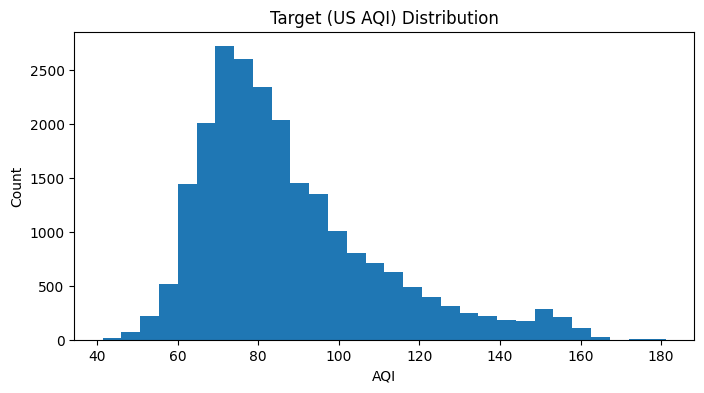

In [36]:
# Target Distribution
plt.figure(figsize=(8,4))
plt.hist(df["target"], bins=30)
plt.title("Target (US AQI) Distribution")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.show()

In [37]:
# Correlation matrix of target with other features
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

corr["target"].sort_values(ascending=False)

target                  1.000000
pm2_5                   0.725189
so2                     0.515994
co                      0.460926
pressure_msl            0.413277
no2                     0.363317
pm10                    0.245162
o3                      0.149353
precipitation          -0.028219
cloud_cover            -0.174840
relative_humidity_2m   -0.309627
wind_speed_10m         -0.355000
temperature_2m         -0.357352
Name: target, dtype: float64

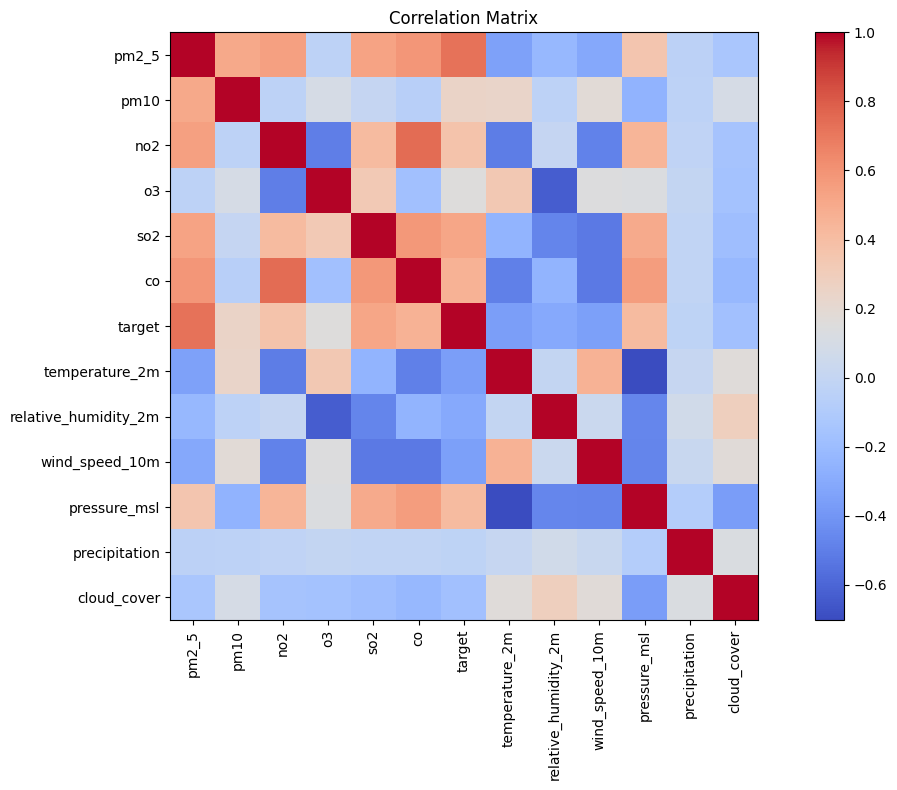

In [39]:
# Correlation heatmap
plt.figure(figsize=(12,8))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

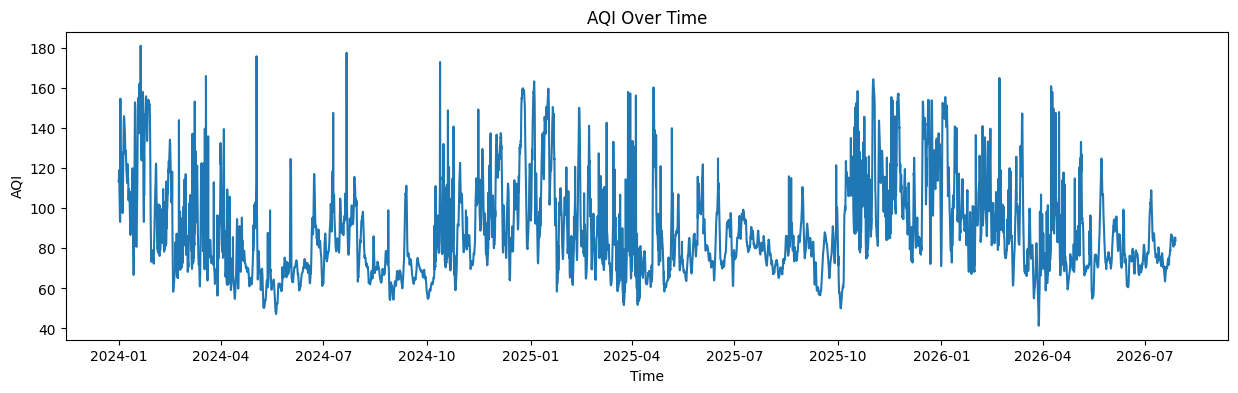

In [40]:
# Target over time
plt.figure(figsize=(15,4))
plt.plot(df["timestamp"], df["target"])
plt.title("AQI Over Time")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.show()

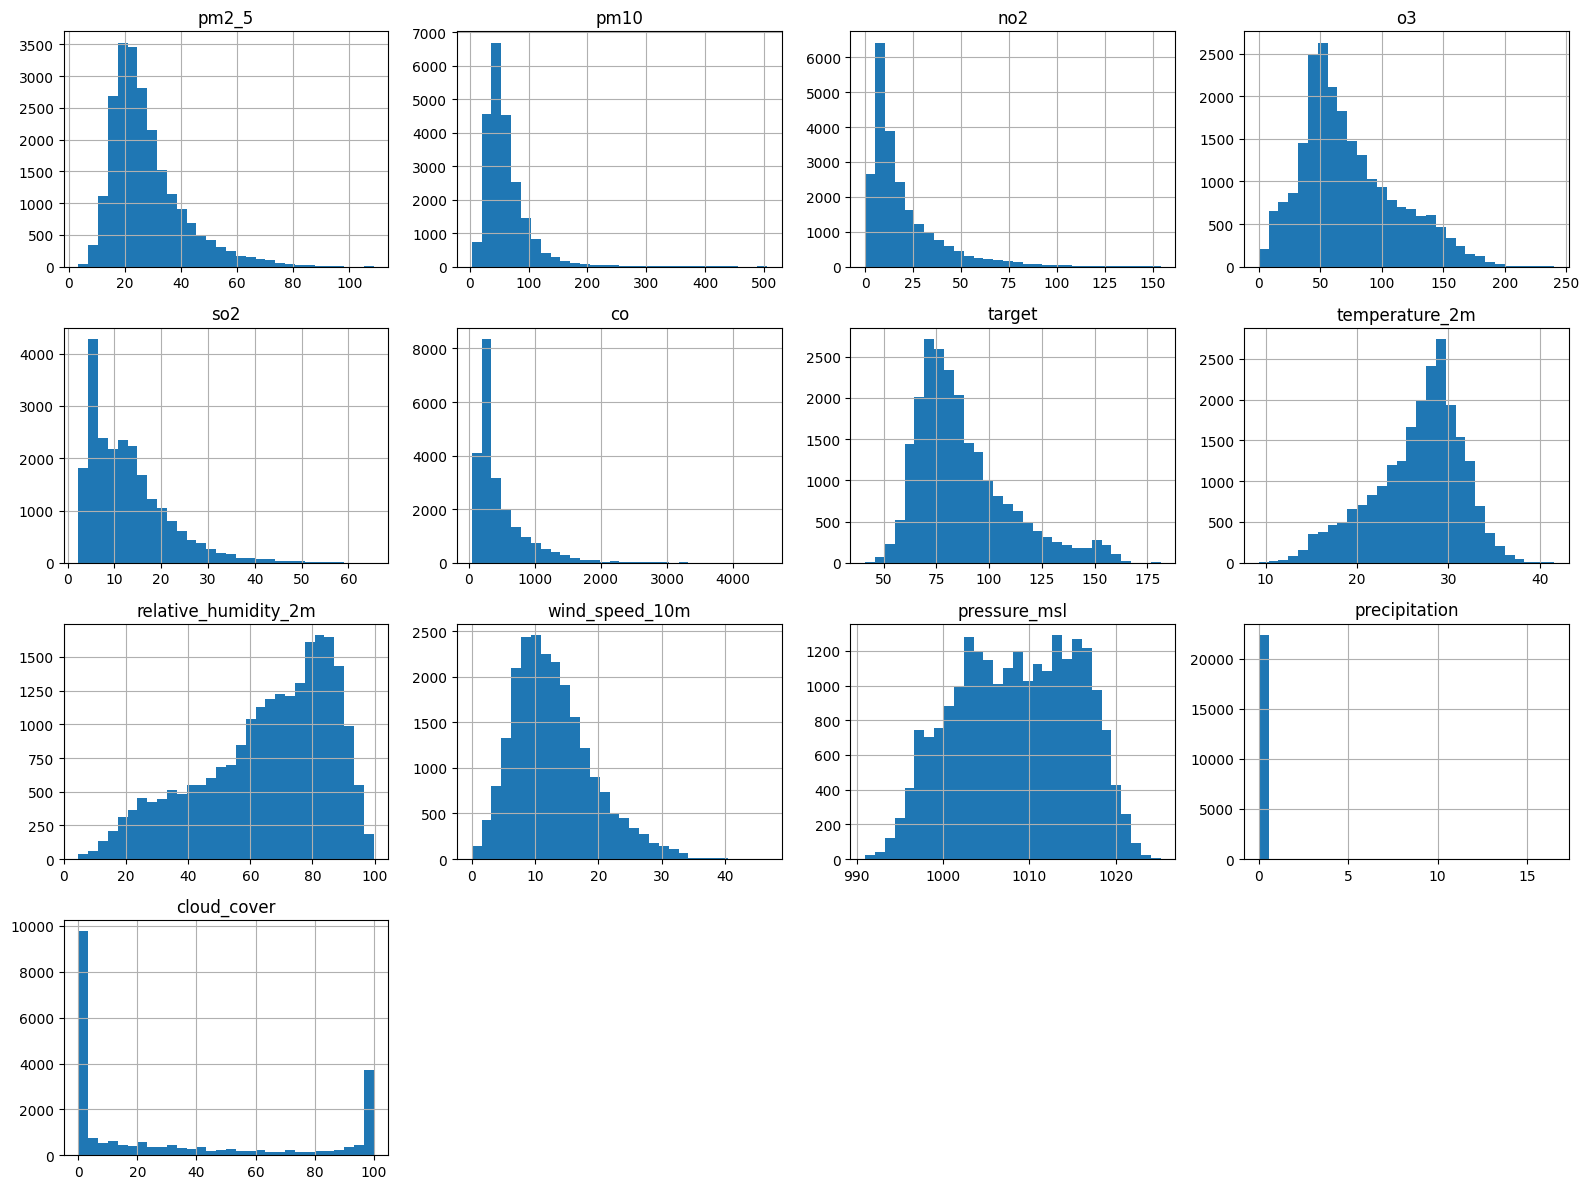

In [41]:
# Feature Distributions
numeric_df.hist(figsize=(16,12), bins=30)
plt.tight_layout()
plt.show()